# CPU Usage Forecasting with CatBoost (Time Series K-Fold Cross-Validation)
Прогнозирование загрузки CPU на 2-3 минуты с k-fold кросс-валидацией для временных рядов (чистый датасет)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/cpu_dataset.csv')
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nCPU stats:\n{df['cpu_usage_percent'].describe()}")

Shape: (30154, 2)

Columns: ['timestamp', 'cpu_usage_percent']

CPU stats:
count    30154.000000
mean        49.382442
std         21.513230
min         18.552542
25%         23.466102
50%         52.750424
75%         68.015254
max         99.616102
Name: cpu_usage_percent, dtype: float64


In [2]:
# 2-3 minutes = 8-12 points (at 15-second intervals)
FORECAST_HORIZON = 10  # 10 * 15 sec = 2.5 minutes

# Create lagged features
def create_features(df, horizon=FORECAST_HORIZON, lags=[1, 2, 3, 4, 5, 8, 12, 16, 20]):
    df = df.copy()
    
    # Lag features
    for lag in lags:
        df[f'cpu_lag_{lag}'] = df['cpu_usage_percent'].shift(lag)
    
    # Rolling statistics (short-term patterns)
    for window in [4, 8, 12]:
        df[f'cpu_rolling_mean_{window}'] = df['cpu_usage_percent'].rolling(window).mean()
        df[f'cpu_rolling_std_{window}'] = df['cpu_usage_percent'].rolling(window).std()
        df[f'cpu_rolling_min_{window}'] = df['cpu_usage_percent'].rolling(window).min()
        df[f'cpu_rolling_max_{window}'] = df['cpu_usage_percent'].rolling(window).max()
    
    # Target: CPU value in FORECAST_HORIZON steps
    df['cpu_target'] = df['cpu_usage_percent'].shift(-horizon)
    
    return df

df_features = create_features(df, horizon=FORECAST_HORIZON)
print(f"Features created. Shape: {df_features.shape}")

Features created. Shape: (30154, 24)


In [3]:
# Remove rows with NaN values
df_clean = df_features.dropna().reset_index(drop=True)
print(f"After removing NaN: {df_clean.shape}")
print(f"Removed {df_features.shape[0] - df_clean.shape[0]} rows")

# Time series k-fold cross-validation (respects temporal order)
from sklearn.model_selection import TimeSeriesSplit

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print(f"\n🎯 Time Series {n_splits}-Fold Cross-Validation:")
print(f"{'Fold':>6} {'Train_Start':>19} {'Train_End':>19} {'Test_Start':>19} {'Test_End':>19} {'Train':>8} {'Test':>8}")
print("-" * 110)

from datetime import datetime
splits = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(df_clean)):
    splits.append((train_idx, test_idx))

    train_times = pd.to_datetime(df_clean.iloc[train_idx]['timestamp'], unit='s')
    test_times = pd.to_datetime(df_clean.iloc[test_idx]['timestamp'], unit='s')

    print(f"{fold+1:>6} {str(train_times.min()):>19} {str(train_times.max()):>19} {str(test_times.min()):>19} {str(test_times.max()):>19} {len(train_idx):>8} {len(test_idx):>8}")

print("-" * 110)

After removing NaN: (30124, 24)
Removed 30 rows

🎯 Time Series 5-Fold Cross-Validation:
  Fold         Train_Start           Train_End          Test_Start            Test_End    Train     Test
--------------------------------------------------------------------------------------------------------------
     1 2026-05-25 18:47:00 2026-05-26 15:42:00 2026-05-26 15:42:15 2026-05-27 12:36:15     5024     5020
     2 2026-05-25 18:47:00 2026-05-27 12:36:15 2026-05-27 12:36:30 2026-05-28 09:30:15    10044     5020
     3 2026-05-25 18:47:00 2026-05-28 09:30:15 2026-05-28 09:30:30 2026-05-29 06:24:30    15064     5020
     4 2026-05-25 18:47:00 2026-05-29 06:24:30 2026-05-29 06:24:45 2026-05-30 03:18:30    20084     5020
     5 2026-05-25 18:47:00 2026-05-30 03:18:30 2026-05-30 03:18:45 2026-05-31 00:12:45    25104     5020
--------------------------------------------------------------------------------------------------------------


In [4]:
# Feature selection (only CPU lags and rolling stats)
lag_features = [col for col in df_clean.columns if 'cpu_lag' in col or 'cpu_rolling' in col]
feature_cols = lag_features

print(f"Features: {len(feature_cols)}")
print(f"Total data points: {len(df_clean)}")

# Train CatBoost model using k-fold cross-validation
fold_results = []
models = []

print("\n" + "="*80)
print("TRAINING MODELS WITH TIME SERIES K-FOLD CROSS-VALIDATION")
print("="*80)

for fold, (train_idx, test_idx) in enumerate(splits):
    print(f"\n🔄 Fold {fold + 1}/{n_splits}")
    
    X_train = df_clean.iloc[train_idx][feature_cols]
    y_train = df_clean.iloc[train_idx]['cpu_target']
    
    X_test = df_clean.iloc[test_idx][feature_cols]
    y_test = df_clean.iloc[test_idx]['cpu_target']
    
    train_pool = Pool(X_train, y_train)
    test_pool = Pool(X_test, y_test)
    
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=7,
        loss_function='MAE',
        eval_metric='MAE',
        verbose=0,
        random_state=42,
        task_type='CPU'
    )
    
    model.fit(train_pool, eval_set=test_pool)
    models.append(model)
    
    # Evaluate
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2 = r2_score(y_test, y_pred_test)
    
    fold_results.append({
        'fold': fold + 1,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'y_test': y_test,
        'y_pred_test': y_pred_test
    })
    
    print(f"  Train MAE: {train_mae:.4f}%")
    print(f"  Test MAE:  {test_mae:.4f}%")
    print(f"  Test RMSE: {test_rmse:.4f}%")
    print(f"  Test R²:   {test_r2:.4f}")

print("\n" + "="*80)

Features: 21
Total data points: 30124

TRAINING MODELS WITH TIME SERIES K-FOLD CROSS-VALIDATION

🔄 Fold 1/5
  Train MAE: 0.5904%
  Test MAE:  2.6291%
  Test RMSE: 4.0769%
  Test R²:   0.9590

🔄 Fold 2/5
  Train MAE: 0.7412%
  Test MAE:  1.2194%
  Test RMSE: 2.0628%
  Test R²:   0.9918

🔄 Fold 3/5
  Train MAE: 0.8161%
  Test MAE:  1.0882%
  Test RMSE: 1.8898%
  Test R²:   0.9932

🔄 Fold 4/5
  Train MAE: 0.8439%
  Test MAE:  1.0064%
  Test RMSE: 1.6274%
  Test R²:   0.9947

🔄 Fold 5/5
  Train MAE: 0.8684%
  Test MAE:  1.1371%
  Test RMSE: 2.2670%
  Test R²:   0.9817



In [5]:
# Detailed analysis of time series k-fold splits
print("\n" + "="*80)
print("DETAILED ANALYSIS OF TIME SERIES K-FOLD SPLITS")
print("="*80)

results_df = pd.DataFrame(fold_results)

print("\n📊 CROSS-VALIDATION RESULTS:")
print(results_df[['fold', 'train_mae', 'test_mae', 'test_rmse', 'test_r2']].to_string(index=False))

print("\n📈 AVERAGED METRICS:")
print(f"  Average Train MAE:  {results_df['train_mae'].mean():.4f}%")
print(f"  Average Test MAE:   {results_df['test_mae'].mean():.4f}%")
print(f"  Average Test RMSE:  {results_df['test_rmse'].mean():.4f}%")
print(f"  Average Test R²:    {results_df['test_r2'].mean():.4f}")
print(f"\n  Std Dev Test MAE:   {results_df['test_mae'].std():.4f}%")
print(f"  Std Dev Test R²:    {results_df['test_r2'].std():.4f}")

print("\n" + "="*80)


DETAILED ANALYSIS OF TIME SERIES K-FOLD SPLITS

📊 CROSS-VALIDATION RESULTS:
 fold  train_mae  test_mae  test_rmse  test_r2
    1   0.590393  2.629117   4.076908 0.959007
    2   0.741210  1.219405   2.062807 0.991845
    3   0.816133  1.088210   1.889790 0.993212
    4   0.843868  1.006426   1.627412 0.994743
    5   0.868392  1.137054   2.267008 0.981733

📈 AVERAGED METRICS:
  Average Train MAE:  0.7720%
  Average Test MAE:   1.4160%
  Average Test RMSE:  2.3848%
  Average Test R²:    0.9841

  Std Dev Test MAE:   0.6825%
  Std Dev Test R²:    0.0149



In [6]:
# Train final model on full data for feature importance and predictions
print("\n🔄 Training final model on entire dataset for inference...")

train_pool = Pool(df_clean[feature_cols], df_clean['cpu_target'])

final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function='MAE',
    eval_metric='MAE',
    verbose=0,
    random_state=42,
    task_type='CPU'
)

final_model.fit(train_pool)
print("✓ Final model trained on full data")


🔄 Training final model on entire dataset for inference...
✓ Final model trained on full data


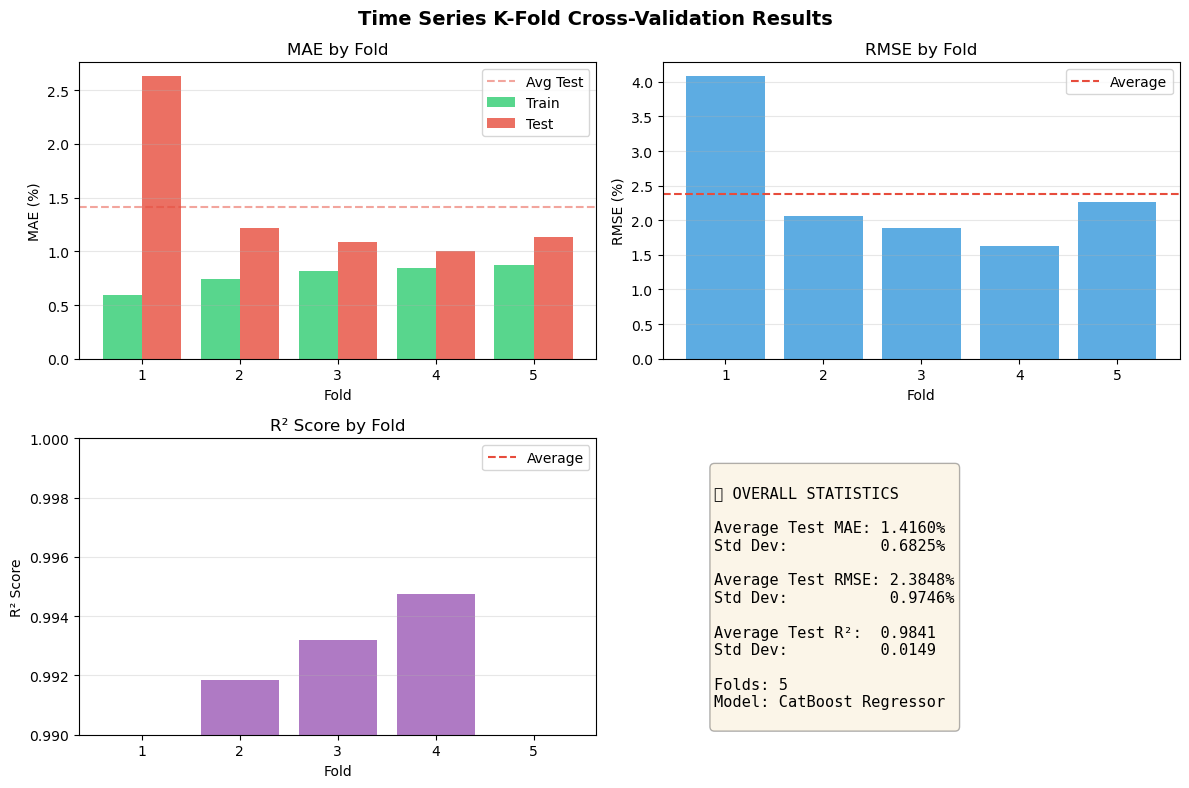

In [7]:
# Visualize cross-validation results
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Time Series K-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

folds = results_df['fold']
x_pos = np.arange(len(folds))

# MAE comparison
axes[0, 0].bar(x_pos - 0.2, results_df['train_mae'], 0.4, label='Train', alpha=0.8, color='#2ecc71')
axes[0, 0].bar(x_pos + 0.2, results_df['test_mae'], 0.4, label='Test', alpha=0.8, color='#e74c3c')
axes[0, 0].axhline(results_df['test_mae'].mean(), color='#e74c3c', linestyle='--', alpha=0.5, label='Avg Test')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('MAE (%)')
axes[0, 0].set_title('MAE by Fold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(folds)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# RMSE
axes[0, 1].bar(x_pos, results_df['test_rmse'], alpha=0.8, color='#3498db')
axes[0, 1].axhline(results_df['test_rmse'].mean(), color='#e74c3c', linestyle='--', label='Average')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('RMSE (%)')
axes[0, 1].set_title('RMSE by Fold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(folds)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# R² Score
axes[1, 0].bar(x_pos, results_df['test_r2'], alpha=0.8, color='#9b59b6')
axes[1, 0].axhline(results_df['test_r2'].mean(), color='#e74c3c', linestyle='--', label='Average')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_title('R² Score by Fold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(folds)
axes[1, 0].set_ylim([0.99, 1.0])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Overall statistics
axes[1, 1].axis('off')
stats_text = f"""
📊 OVERALL STATISTICS

Average Test MAE: {results_df['test_mae'].mean():.4f}%
Std Dev:          {results_df['test_mae'].std():.4f}%

Average Test RMSE: {results_df['test_rmse'].mean():.4f}%
Std Dev:           {results_df['test_rmse'].std():.4f}%

Average Test R²:  {results_df['test_r2'].mean():.4f}
Std Dev:          {results_df['test_r2'].std():.4f}

Folds: {n_splits}
Model: CatBoost Regressor
"""
axes[1, 1].text(0.1, 0.9, stats_text, transform=axes[1, 1].transAxes, fontsize=11,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()


Top 15 Important Features:
            feature  importance
  cpu_rolling_min_4    9.482519
  cpu_rolling_min_8    9.191426
  cpu_rolling_max_8    8.925867
 cpu_rolling_max_12    8.511809
          cpu_lag_1    6.897969
 cpu_rolling_mean_8    6.493909
          cpu_lag_2    5.763349
cpu_rolling_mean_12    5.093881
         cpu_lag_20    3.937967
          cpu_lag_3    3.851023
          cpu_lag_4    3.778103
          cpu_lag_5    3.678988
 cpu_rolling_std_12    3.589796
 cpu_rolling_mean_4    3.118928
  cpu_rolling_max_4    3.118194


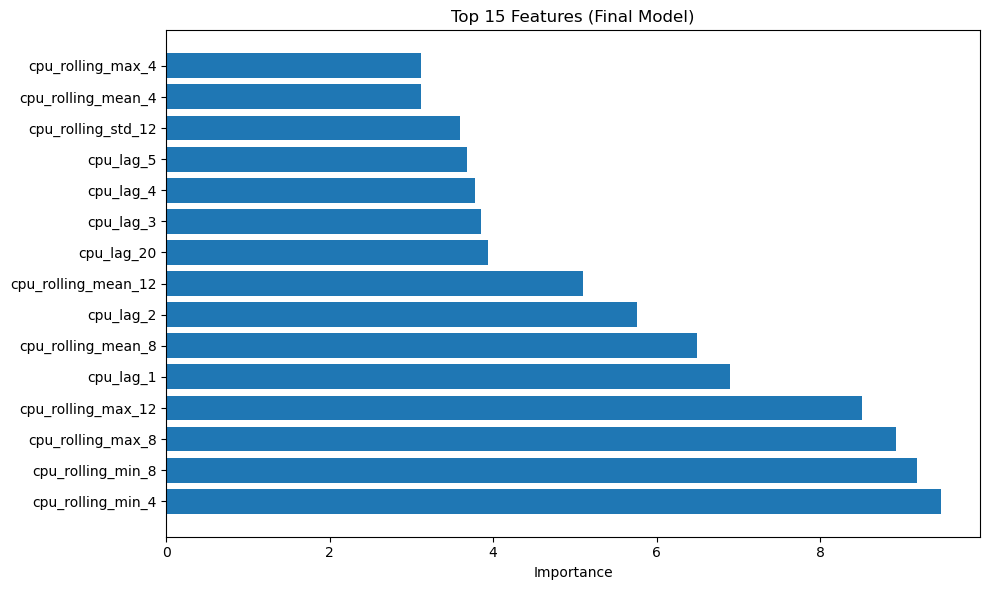

In [8]:
# Feature importance from final model
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features (Final Model)')
plt.tight_layout()
plt.show()

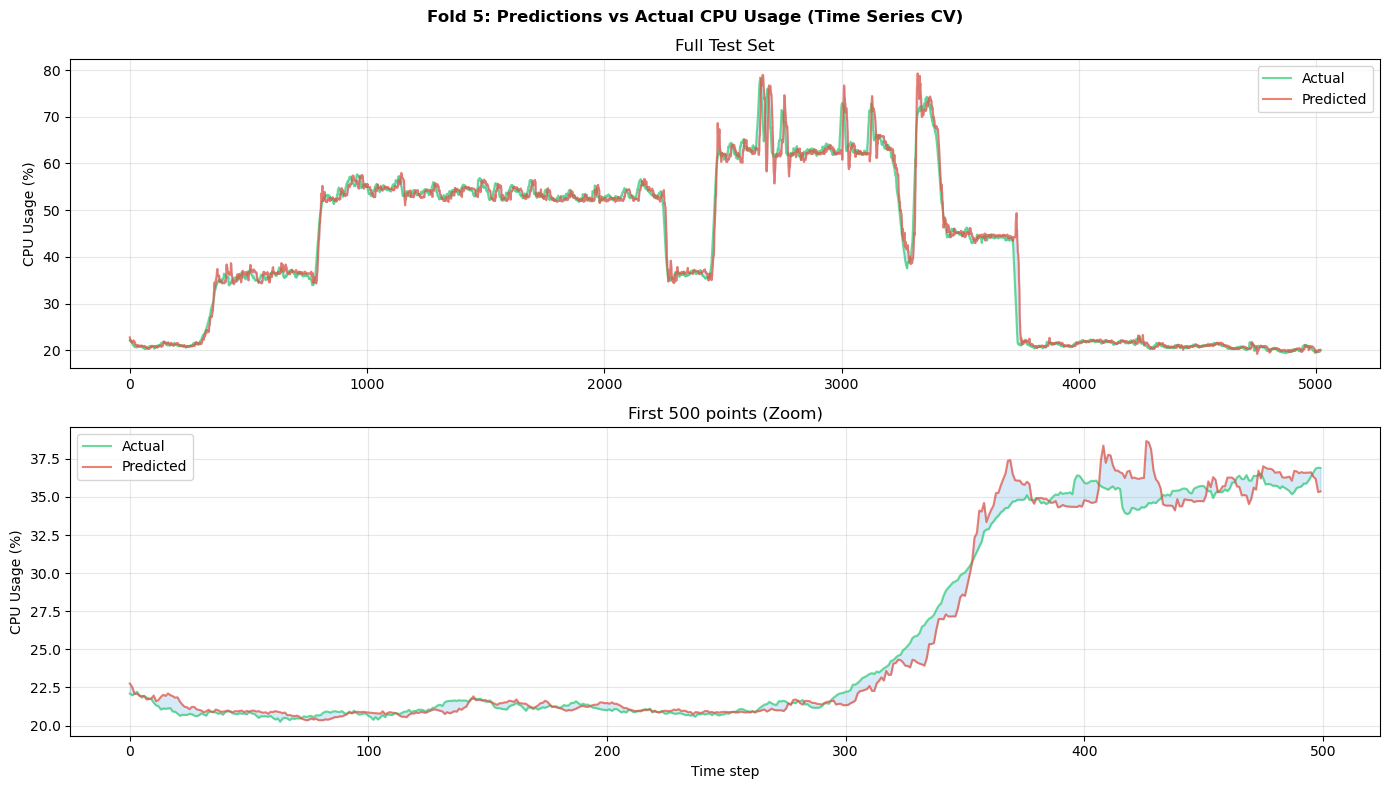


Prediction error distribution (Fold 5 test set):
  Min error: 0.000%
  Median error: 0.533%
  Max error: 23.370%
  95th percentile: 4.428%


In [9]:
# Visualization: predictions vs actual (using last fold as example)
last_fold_result = fold_results[-1]
y_test_last = last_fold_result['y_test']
y_pred_last = last_fold_result['y_pred_test']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(f"Fold {last_fold_result['fold']}: Predictions vs Actual CPU Usage (Time Series CV)", fontsize=12, fontweight='bold')

test_range = range(len(y_test_last))
axes[0].plot(test_range, y_test_last.values, label='Actual', alpha=0.7, linewidth=1.5, color='#2ecc71')
axes[0].plot(test_range, y_pred_last, label='Predicted', alpha=0.7, linewidth=1.5, color='#e74c3c')
axes[0].fill_between(test_range, y_test_last.values, y_pred_last, alpha=0.2, color='#3498db')
axes[0].set_title('Full Test Set')
axes[0].set_ylabel('CPU Usage (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

zoom_range = range(min(500, len(y_test_last)))
axes[1].plot(zoom_range, y_test_last.values[:500], label='Actual', alpha=0.7, linewidth=1.5, color='#2ecc71')
axes[1].plot(zoom_range, y_pred_last[:500], label='Predicted', alpha=0.7, linewidth=1.5, color='#e74c3c')
axes[1].fill_between(zoom_range, y_test_last.values[:500], y_pred_last[:500], alpha=0.2, color='#3498db')
axes[1].set_title('First 500 points (Zoom)')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('CPU Usage (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrediction error distribution (Fold {last_fold_result['fold']} test set):")
errors = np.abs(y_test_last.values - y_pred_last)
print(f"  Min error: {errors.min():.3f}%")
print(f"  Median error: {np.median(errors):.3f}%")
print(f"  Max error: {errors.max():.3f}%")
print(f"  95th percentile: {np.percentile(errors, 95):.3f}%")

In [10]:
# Save final model
final_model.save_model('../models/cpu_forecast_model.cbm')
print("✓ Model saved as 'cpu_forecast_model.cbm'")

import json
with open('../models/cpu_model_config.json', 'w') as f:
    json.dump({
        'feature_cols': feature_cols,
        'forecast_horizon': FORECAST_HORIZON,
        'lag_features': [1, 2, 3, 4, 5, 8, 12, 16, 20],
        'rolling_windows': [4, 8, 12],
        'cv_method': 'TimeSeriesSplit',
        'n_folds': n_splits,
        'avg_test_mae': float(results_df['test_mae'].mean()),
        'avg_test_rmse': float(results_df['test_rmse'].mean()),
        'avg_test_r2': float(results_df['test_r2'].mean())
    }, f, indent=2)
print("✓ Config saved as 'cpu_model_config.json'")

✓ Model saved as 'cpu_forecast_model.cbm'
✓ Config saved as 'cpu_model_config.json'
